In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.collections import LineCollection
from src.results_paper import *
from src.TimeSeriesAnalysis import *
from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output

In [2]:
results_folder = "../results/TimeSeries/2D"
create_folder(results_folder)

In [ ]:
L_lst   = [512, 1024, 2048]
DIM = 2
NT  = 200
K   = 1.0e-04

NC_list  = [1]
RHO_list = [1.0]
for L in L_lst:
    compute_means_for_folder(2048, DIM, NT, K, NC_list, RHO_list)

KeyError: 'order_percolation 1'

## 1 COLOR

In [8]:
savepath_TS = "../results/TimeSeries/2D"
create_folder(savepath_TS)

In [ ]:
process_all_roots("../Data/bond_percolation", verbose=True, clean_outputs=False)
summarize_all_dirs("../Data/bond_percolation", verbose=True)
clear_output()

In [29]:
df = pd.read_csv("../Data/bond_percolation/all_data_3D.dat", sep=' ').sort_values(by="rho")
df

,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
3174,512,3000,0.000001,2,0.011030,1.0,0.1,1,50,0.250182,0.000059,2850.780,29.863066,9539302.540,74998.156117
3175,512,3000,0.000001,2,0.011030,1.0,0.1,2,50,0.250117,0.000059,2955.000,24.991884,9540105.360,75031.676194
2872,512,3000,0.000001,2,0.013538,1.0,0.1,1,50,0.250046,0.000060,2803.360,28.682509,9373935.240,81298.242872
2873,512,3000,0.000001,2,0.013538,1.0,0.1,2,50,0.250218,0.000058,2899.700,27.087119,9374516.820,81230.615244
3082,512,3000,0.000001,2,0.016045,1.0,0.1,1,50,0.250156,0.000059,2891.320,27.316773,9633124.940,77766.680260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3363,128,3000,0.000001,2,0.497490,1.0,0.1,2,500,0.368663,0.000480,144.844,0.203219,992574.624,3070.589961
2542,256,3000,0.000001,2,0.500000,1.0,0.1,1,100,0.256731,0.000062,790.800,1.962631,3117258.750,5640.954449
3278,128,3000,0.000001,2,0.500000,1.0,0.1,1,500,0.556922,0.000929,144.390,0.165658,897404.110,2668.764902
2543,256,3000,0.000001,2,0.500000,1.0,0.1,2,100,0.256894,0.000067,798.020,1.846590,3117092.460,5648.742550


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from matplotlib.ticker import LinearLocator, AutoMinorLocator, FormatStrFormatter

def aplicar_ticks(ax, n_xticks=6, n_yticks=6, yfmt='%.3f'):
    # coloque isto DEPOIS de set_xlim/set_ylim
    ax.xaxis.set_major_locator(LinearLocator(n_xticks))
    ax.yaxis.set_major_locator(LinearLocator(n_yticks))
    
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    ax.yaxis.set_major_formatter(FormatStrFormatter(yfmt))  # opcional

nc_list = [2, 4, 8]
k = 1.0e-06
NT = 3000
p0 = 1.0
L_list = [512, 1024]
pc_ref = 0.5

ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=True, sharey=True, constrained_layout=True)

labels_fig = ["$(a)$", "$(b)$", "$(c)$", "$(d)$", "$(e)$", "$(f)$"]
labels_Ns = [r"$N_s = 100$", "$N_s = 50$"]
legend_lines = {}  # guarda um Line2D por índice i

for i_row, L in enumerate(L_list):
    for j_col, nc_val in enumerate(nc_list):
        ax = axes[i_row, j_col]
        rho = 0.125
        filename = (
            f"../Data/bond_percolation/num_colors_{nc_val}/dim_2/"
            f"L_{L}/NT_constant/NT_20/k_1.0e-04/rho_{rho:.4e}/all_data_bundle.json"
        )

        try:
            bundle, df = read_all_data_bundle(filename, as_dataframe=True)
        except Exception:
            ax.text(0.5, 0.5, "arquivo não encontrado\nou erro ao ler",
                    ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_title(fr"$L={L}$, $n_c={nc_val}$")
            continue

        if df.empty:
            ax.text(0.5, 0.5, "sem dados", ha='center', va='center',
                    transform=ax.transAxes, fontsize=10)
            ax.set_title(fr"$L={L}$, $n_c={nc_val}$")
            continue

        orders = np.sort(df['order'].unique())
        x_max = 0.0

        for idx_ord, ord_val in enumerate(orders, start=1):
            df_f = df[df['order'] == ord_val]
            if df_f.empty:
                continue

            line, = ax.plot(df_f['t'], df_f['pt'],
                            lw=1.8,
                            ls=ls[idx_ord-1],  # <- corrige o off-by-one
                            label=fr'$i={idx_ord}$')

            # guarde o primeiro artista de cada i para a legenda global
            if idx_ord not in legend_lines:
                legend_lines[idx_ord] = line

            if len(df_f['t']) and np.nanmax(df_f['t']) > x_max:
                x_max = float(np.nanmax(df_f['t']))

        ax.set_title(fr"$L={L}$, $n_c={nc_val}$")
        if x_max > 0:
            ax.set_xlim(0, int(x_max))
        ax.axhline(y=pc_ref, ls='--', lw=1.6, color='k')

        if j_col == 0:
            ax.set_ylabel(r'$\langle p(t) \rangle$')
            ax.text(0.95, 0.85, labels_Ns[i_row],
                transform=ax.transAxes, ha='right', va='bottom', fontsize=25)
        
        if i_row == len(L_list) - 1:
            ax.set_xlabel(r'$t$')

        if i_row != 0:
            ax.set_ylim(0.22, 0.30)

        ax.set_xlim(0, 500)

        aplicar_ticks(ax, n_xticks=6, n_yticks=6)
        if i_row != len(L_list) - 1:        # esconde nas linhas de cima
            ax.tick_params(axis='x', which='both', labelbottom=False)
        else:                                # mostra só na última linha
            ax.tick_params(axis='x', which='both', labelbottom=True)
        
        if j_col != 0:
            ax.tick_params(axis='y', which='both', labelleft=False)

        # Adiciona os labels nos cantos inferiores direitos
        ax.text(0.95, 0.05, labels_fig[i_row * len(nc_list) + j_col],
                transform=ax.transAxes, ha='right', va='bottom', fontsize=25)
         
# ===== legenda global usando os próprios artistas =====
fig.subplots_adjust(right=0.82)

# ordena por i e cria listas
handles = [legend_lines[i] for i in sorted(legend_lines.keys())]
labels = [fr'$i={i}$' for i in sorted(legend_lines.keys())]

# adiciona o handle do p_c
pc_handle = Line2D([0], [0], linestyle='--', linewidth=1.6, color='k')
handles.append(pc_handle)
labels.append(fr'$p_c={pc_ref}$')

fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
           frameon=False)
fig.suptitle(fr"$\rho={rho}$, $k = {k:.1e}$, $N_t = {NT}$", fontsize=25, fontweight='bold')  # Adds a title to the entire figure

plt.savefig(results_folder + "/TimeSeries_L_and_nc_multi_samples.pdf")
plt.show()


In [8]:
L = 2048
k = 2.0e-04
Nt = 200
dim = 2
rho = 1.0
prop = "Pt"
num_colors = 1
type_perc = 'node'
filename = "P0_0.10_p0_0.40_seed_13970049.json"
path = f"../Data/{type_perc}_percolation/num_colors_{num_colors}/dim_{dim}/L_{L}/NT_constant/NT_{Nt}/k_{k:.1e}/rho_{rho:.4e}/data/"
path_json = path + filename

metas, df = load_bundle_old(path_json)
df

,order,t,pt,nt
0,1,0,0.4000,20.0
1,1,1,0.4370,15.0
2,1,2,0.4746,12.0
3,1,3,0.5120,13.0
4,1,4,0.5492,14.0
...,...,...,...,...
4913,1,4913,0.5560,176.0
4914,1,4914,0.5626,167.0
4915,1,4915,0.5654,186.0
4916,1,4916,0.5672,191.0


In [10]:
# Create data with a lot of samples
L = 2048
k = 2.0e-04
Nt = 200
dim = 2
rho = 1.0
num_colors = 1
p_0_node = [0.4, 0.8, 1.0]
p_0_bond = [0.3, 0.7, 1.0]
type_perc = ["bond", "node"]
for type in type_perc:
    p0 = p_0_bond if type=='bond' else p_0_node
    compute_means_for_folder_new(type, num_colors,dim, L, Nt, k, 1.0, p0,window_roll=100)

[ok] p0=0.30: 1000 arquivos | seeds=1000 | pc_SOP=0.504584±0.000074 | pc_SOP^roll: T=4616, seeds_valid=958, win=100
[ok] p0=0.70: 1000 arquivos | seeds=1000 | pc_SOP=0.502257±0.000041 | pc_SOP^roll: T=4627, seeds_valid=963, win=100
[ok] p0=1.00: 1000 arquivos | seeds=1000 | pc_SOP=0.502565±0.000034 | pc_SOP^roll: T=4529, seeds_valid=960, win=100
[salvo] ../Data/bond_percolation/num_colors_1/dim_2/L_2048/NT_constant/NT_200/k_2.0e-04/rho_1.0000e+00/properties_mean_bundle.json
[ok] p0=0.40: 1000 arquivos | seeds=1000 | pc_SOP=0.596603±0.000049 | pc_SOP^roll: T=3919, seeds_valid=997, win=100
[ok] p0=0.80: 1000 arquivos | seeds=1000 | pc_SOP=0.595606±0.000040 | pc_SOP^roll: T=3874, seeds_valid=996, win=100
[ok] p0=1.00: 1000 arquivos | seeds=1000 | pc_SOP=0.595796±0.000038 | pc_SOP^roll: T=3991, seeds_valid=994, win=100
[salvo] ../Data/node_percolation/num_colors_1/dim_2/L_2048/NT_constant/NT_200/k_2.0e-04/rho_1.0000e+00/properties_mean_bundle.json


In [2]:
import os
import json

def load_full_bundle(type_perc, num_colors, dim, L, NT, k, rho, *, return_path: bool = False, must_exist: bool = True):
    """
    Lê o arquivo:
      ../Data/<type_perc>_percolation/num_colors_<num_colors>/dim_<dim>/L_<L>/NT_constant/NT_<NT>/k_<k_fmt>/rho_<rho_fmt>/properties_mean_bundle.json

    Parâmetros
    ----------
    type_perc : str
        "bond" ou "node" (ou o que você usa no pipeline)
    num_colors : int
    dim : int
    L : int
    NT : int
    k : float
    rho : float
    return_path : bool, opcional (default=False)
        Se True, retorna (bundle_dict, caminho_arquivo). Caso contrário, retorna apenas o dict.
    must_exist : bool, opcional (default=True)
        Se True, dispara FileNotFoundError se o arquivo não existir.
        Se False, retorna ({}, None) quando não encontrado (ou apenas {} se return_path=False).

    Retorno
    -------
    dict (ou (dict, str)):
        O conteúdo completo do JSON como dicionário Python, para você navegar livremente nas keys.
        Se return_path=True, retorna uma tupla (bundle, bundle_path).

    Exceções
    --------
    FileNotFoundError:
        Se must_exist=True e o arquivo não for encontrado.
    json.JSONDecodeError:
        Se o arquivo existir, mas não puder ser decodificado como JSON.
    """
    base_dir = "../Data"
    out_dir = os.path.join(
        base_dir,
        f"{type_perc}_percolation",
        f"num_colors_{num_colors}",
        f"dim_{dim}",
        f"L_{L}",
        "NT_constant",
        f"NT_{NT}",
        f"k_{k:.1e}",
        f"rho_{rho:.4e}",
    )
    bundle_path = os.path.join(out_dir, "properties_mean_bundle.json")

    if not os.path.isfile(bundle_path):
        if must_exist:
            raise FileNotFoundError(
                f"Bundle não encontrado: {bundle_path}\n"
                f"(Gere com compute_means_for_folder_new)"
            )
        else:
            return ({}, bundle_path) if return_path else {}

    with open(bundle_path, "r", encoding="utf-8") as f:
        bundle = json.load(f)

    return (bundle, bundle_path) if return_path else bundle


In [3]:
L = 2048
k = 2.0e-04
NT = 200
dim = 2
rho = 1.0
num_colors = 1
type_perc = 'bond'
B = load_full_bundle(type_perc, num_colors, dim, L, NT, k, rho)
for keys in B['p0_groups'][0]:
    print(keys)


FileNotFoundError: Bundle não encontrado: ../Data/bond_percolation/num_colors_1/dim_2/L_2048/NT_constant/NT_200/k_2.0e-04/rho_1.0000e+00/properties_mean_bundle.json
(Gere com compute_means_for_folder_new)

In [14]:
def load_bundle_old(
    filepath: str | Path,
    *,
    include_nt: bool = True
) -> Tuple[List[Dict[str, Any]], pd.DataFrame]:
    """
    Lê um arquivo .json de simulação e retorna:
      - metas: lista de dicts com metadados por 'order_percolation'
      - df: DataFrame longo com colunas ['order','t','pt','nt'] (nt pode vir NaN)

    Suporta JSONs nos formatos:
      A) { "results": [ {"order_percolation":int, "data":{...}}, ... ] }
      B) { "orders" | "data" :  dict/list de blocos por ordem }
      C) diretamente uma lista/dict de ordens

    Parâmetros
    ----------
    filepath : str | Path
        Caminho do arquivo JSON.
    include_nt : bool
        Se True, tenta carregar a série 'nt' quando existir; caso contrário, preenche NaN.

    Retorno
    -------
    metas : list[dict]
        Para cada ordem/bloco:
        {'order', 'color', 'rho', 'M_size', 'time_percolation', 'n_time', 'has_nt'}.
    df : pandas.DataFrame
        Linhas por tempo: colunas ['order','t','pt','nt'] (nt pode ser NaN).
    """
    # ---------------- helpers internos ----------------
    def _as_int_safe(x, default=0):
        try:
            return int(x)
        except Exception:
            return default

    def _pick_container(obj: Any):
        """Escolhe onde estão os blocos de ordens."""
        if isinstance(obj, dict):
            for key in ("results", "orders", "Orders", "data"):
                if key in obj:
                    return key, obj[key]
        return None, obj  # pode ser list/dict direto

    def _iter_blocks(container):
        """
        Itera blocos de dados de forma uniforme.
        Cada yield é (order_int, bloco_dict_plano) onde bloco_dict_plano tem campos t/pt/nt etc.
        """
        # Caso lista de blocos
        if isinstance(container, list):
            # ordenar por 'order_percolation' se existir
            ordered = sorted(container, key=lambda b: _as_int_safe(b.get("order_percolation", 0)) if isinstance(b, dict) else 0)
            for blk in ordered:
                if not isinstance(blk, dict):
                    continue
                ordk = _as_int_safe(blk.get("order_percolation", 0))
                data = blk.get("data", blk)
                yield ordk, data
            return

        # Caso dict de ordens
        if isinstance(container, dict):
            items = []
            for k, v in container.items():
                if isinstance(v, dict) and "order_percolation" in v:
                    ordk = _as_int_safe(v.get("order_percolation", 0))
                else:
                    ordk = _as_int_safe(k, 0)
                items.append((ordk, v))
            for ordk, v in sorted(items, key=lambda t: t[0]):
                data = v.get("data", v) if isinstance(v, dict) else {}
                yield ordk, data
            return

        # Fallback: nada reconhecido
        return

    # ---------------- leitura do arquivo ----------------
    filepath = Path(filepath)
    with filepath.open("r", encoding="utf-8") as f:
        obj = json.load(f)

    metas: List[Dict[str, Any]] = []
    rows: List[tuple] = []

    top_key, container = _pick_container(obj)

    # Formato A) results (lista) — caminho "clássico" do seu loader
    if top_key == "results" and isinstance(container, list):
        for item in container:
            if not isinstance(item, dict):
                continue
            order = item.get("order_percolation")
            d = item.get("data", {})
            if order is None or not isinstance(d, dict):
                continue

            # aceita 'time' ou 't'; 'pt' obrigatório para série
            time = d.get("time", d.get("t", None))
            pt   = d.get("pt", None)
            nt   = d.get("nt", None) if include_nt else None

            time = np.asarray(time) if time is not None else None
            pt   = np.asarray(pt)   if pt   is not None else None
            nt   = np.asarray(nt)   if (nt is not None) else None

            if time is None or pt is None:
                n_time = 0
            else:
                n_time = int(min(len(time), len(pt)))
                if nt is not None:
                    n_time = int(min(n_time, len(nt)))
                time = time[:n_time]
                pt   = pt[:n_time]
                if nt is not None:
                    nt = nt[:n_time]
                if n_time > 0:
                    if nt is None:
                        for t, p in zip(time, pt):
                            rows.append((int(order), float(t), float(p), np.nan))
                    else:
                        for t, p, n in zip(time, pt, nt):
                            rows.append((int(order), float(t), float(p), float(n)))

            metas.append({
                "order": int(order),
                "color": d.get("color", None),
                "rho": d.get("rho", None),
                "M_size": d.get("M_size", None),
                "time_percolation": d.get("time_percolation", None),
                "n_time": int(n_time),
                "has_nt": bool(nt is not None)
            })

    else:
        # Formatos B/C) "orders"/"data" (dict/list) ou estrutura direta
        for ordk, d in _iter_blocks(container):
            if not isinstance(d, dict):
                continue
            time = d.get("time", d.get("t", None))
            pt   = d.get("pt", d.get("pt_mean", None))  # aceita 'pt_mean' se vier média por ordem
            nt   = d.get("nt", None) if include_nt else None

            time = np.asarray(time) if time is not None else None
            pt   = np.asarray(pt)   if pt   is not None else None
            nt   = np.asarray(nt)   if (nt is not None) else None

            if time is None or pt is None:
                n_time = 0
            else:
                n_time = int(min(len(time), len(pt)))
                if nt is not None:
                    n_time = int(min(n_time, len(nt)))
                time = time[:n_time]
                pt   = pt[:n_time]
                if nt is not None:
                    nt = nt[:n_time]
                if n_time > 0:
                    if nt is None:
                        for t, p in zip(time, pt):
                            rows.append((int(ordk), float(t), float(p), np.nan))
                    else:
                        for t, p, n in zip(time, pt, nt):
                            rows.append((int(ordk), float(t), float(p), float(n)))

            metas.append({
                "order": int(ordk),
                "color": d.get("color", None),
                "rho": d.get("rho", None),
                "M_size": d.get("M_size", None),
                "time_percolation": d.get("time_percolation", None),
                "n_time": int(n_time),
                "has_nt": bool(nt is not None)
            })

    df = pd.DataFrame(rows, columns=["order", "t", "pt", "nt"]) if rows else \
         pd.DataFrame(columns=["order", "t", "pt", "nt"])

    return metas, df

## PROPERTIES SINGLE SAMPLE

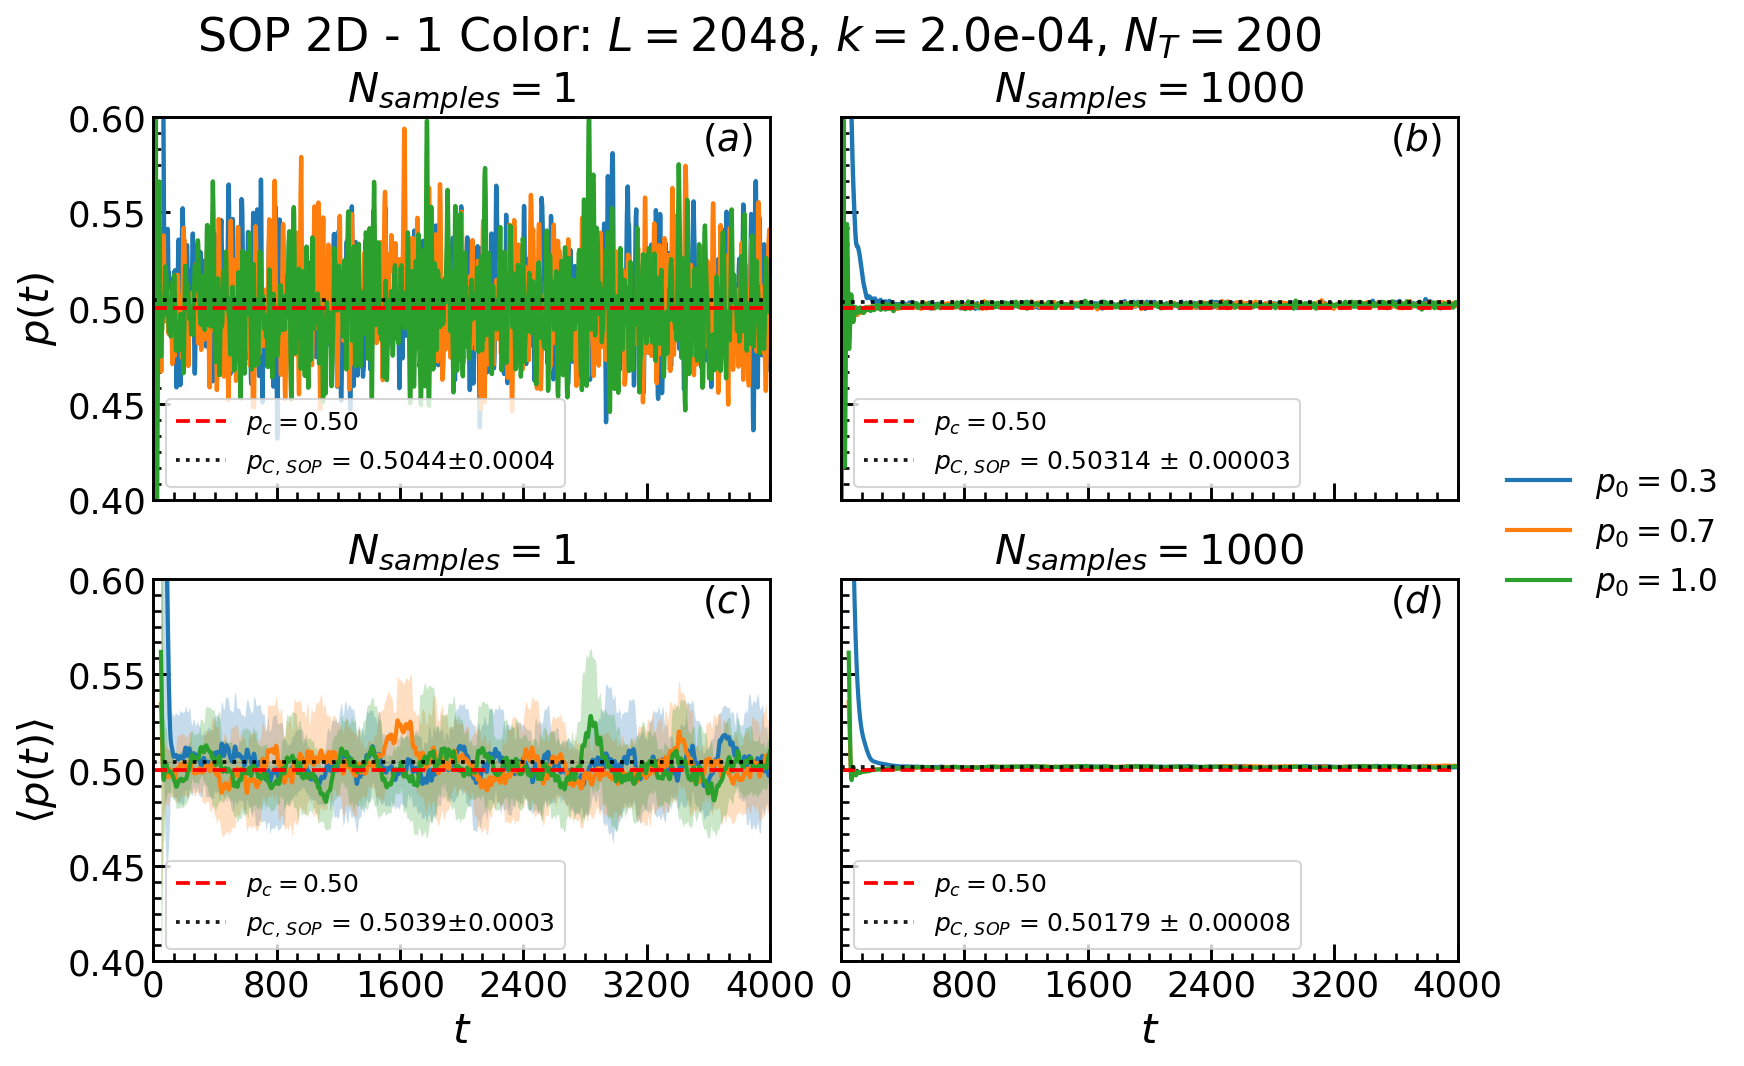

In [15]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import LinearLocator, AutoMinorLocator
from matplotlib.lines import Line2D

# ---- qualidade do PDF / render ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['savefig.dpi']  = 600
mpl.rcParams['figure.dpi']   = 150

# ---------- helpers (bootstrap) ----------
def bootstrap_mean(values, n_boot=20000, rng=None):
    """Retorna (media_boot, std_boot) via bootstrap simples sobre 'values'."""
    values = np.asarray(values, dtype=float)
    if rng is None:
        rng = np.random.default_rng(12345)
    n = values.size
    if n == 0:
        return np.nan, np.nan
    idx = rng.integers(0, n, size=(n_boot, n))
    sample_means = values[idx].mean(axis=1)
    return float(sample_means.mean()), float(sample_means.std(ddof=1))

def add_bootstrap_band(ax, pooled_values, x_max, color='k', lw=1.8, ls=':',
                       alpha_line=0.9, band_alpha=0.15, fmt="{:.4f}",
                       label_prefix=r"$\mu_{\mathrm{boot}}\pm\sigma$"):
    """Plota linha horizontal em μ_boot e faixa ±σ_boot. Retorna handle da linha com label numérico."""
    mu_b, sd_b = bootstrap_mean(pooled_values)
    ln = ax.hlines(mu_b, 0, x_max, color=color, linestyle=ls, lw=lw,
                   alpha=alpha_line, label=rf"{label_prefix} = {fmt.format(mu_b)}±{fmt.format(sd_b)}")
    ax.fill_between([0, x_max], [mu_b - sd_b, mu_b - sd_b], [mu_b + sd_b, mu_b + sd_b],
                    color=color, alpha=band_alpha, linewidth=0)
    return ln

import numpy as np

def propagate_mean_error(p_c_mean, p_c_errors):
    """
    Calcula a média e a propagação do erro para um conjunto de valores independentes.

    Parâmetros
    ----------
    p_c_mean : list[float] | np.ndarray
        Lista ou array com os valores médios p_c_i.
    p_c_errors : list[float] | np.ndarray
        Lista ou array com os erros associados σ_i (mesma ordem de p_c_mean).

    Retorna
    -------
    (p_c_m, p_c_err) : tuple[float, float]
        p_c_m   -> média aritmética simples dos valores
        p_c_err -> erro propagado da média, assumindo erros independentes
    """
    p_c_mean = np.asarray(p_c_mean, dtype=float)
    p_c_errors = np.asarray(p_c_errors, dtype=float)

    if p_c_mean.size == 0:
        return np.nan, np.nan

    N = p_c_mean.size
    p_c_m = np.mean(p_c_mean)
    p_c_err = np.sqrt(np.sum(p_c_errors**2)) / N
    return float(p_c_m), float(p_c_err)

# ---------- figura ----------
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 7), sharex=True, constrained_layout=True)

# ---------- params ----------
L = 2048
k = 2.0e-04
NT = 200
dim = 2
rho = 1.0
num_colors = 1
type_perc = 'bond'

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 17
fontsize_legend = 14
fontsize_labels = 20
thickness = 1.4

p_0_bond = [0.3, 0.7, 1.0]
seeds_name_bond = [73095449, 659078613, 1504789634]
window = 100
x_max = 4000

# --- pools para bootstrap ---
# esquerda: dados brutos
pt_pool_raw = []   # p(t)
# direita: séries suavizadas (médias móveis)
pt_pool_mu  = []   # μ_p(t)

data = load_full_bundle(type_perc, num_colors, dim, L, NT, k, rho)

# --- PLOTS (mantidos) ---
# Topo esquerdo: p(t) bruto
for i in range(len(seeds_name_bond)):
    path = f"../Data/bond_percolation/num_colors_{num_colors}/dim_{dim}/L_{L}/NT_constant/NT_{Nt}/k_{k:.1e}/rho_{rho:.4e}/data/"
    metas, df = load_bundle_old(path + f"P0_0.10_p0_{p_0_bond[i]:.2f}_seed_{seeds_name_bond[i]}.json")
    axs[0, 0].plot(df['t'], df['pt'], lw=1.5*thickness, label="_nolegend_", color=colors[i])
    mask = np.asarray(df["t"]) <= x_max
    pt_pool_raw.append(np.asarray(df["pt"])[mask])

# Topo esquerdo: p(t) all
for i in range(len(p_0_bond)):
    data_filter = data['p0_groups'][i]['orders'][0]['data']
    axs[0, 1].plot(data_filter['time'], data_filter['pt_mean'], lw=1.5*thickness, label="_nolegend_", color=colors[i])
    mask = np.asarray(data_filter['time']) <= x_max
    pt_pool_mu.append(np.asarray(data_filter["pt_mean"])[mask])

# Base esquerda: <p(t)> bruto
for i in range(len(seeds_name_bond)):
    path = f"../Data/bond_percolation/num_colors_{num_colors}/dim_{dim}/L_{L}/NT_constant/NT_{Nt}/k_{k:.1e}/rho_{rho:.4e}/data/"
    metas, df = load_bundle_old(path + f"P0_0.10_p0_{p_0_bond[i]:.2f}_seed_{seeds_name_bond[i]}.json")
    t_center, mean, std = rolling_mean_std(df['t'], df['pt'], window= 100) 
    axs[1, 0].plot(t_center, mean, lw=2.0, color=colors[i], label="_nolegend_")
    axs[1, 0].fill_between(t_center, mean - std, mean + std, alpha=0.25, color=colors[i], linewidth=0)
    # acumula os valores suavizados para bootstrap da coluna direita
    # mask_mu = np.asarray(t_center) <= x_max
    # pt_pool_mu.append(np.asarray(mu)[mask_mu])

# Topo direito: μ_p(t) ± sd
for i, seed in enumerate(seeds_name_bond):
    data_filter = B['p0_groups'][i]['pc_sop_roll']
    tc, mu, sd = data_filter['t_center'], data_filter['mean'], data_filter['std_boot']
    tc, mu, sd = np.array(tc), np.array(mu), np.array(sd)
    axs[1, 1].plot(tc, mu, lw=2.0, color=colors[i], label="_nolegend_")
    axs[1, 1].fill_between(tc, mu - sd, mu + sd, alpha=0.25, color=colors[i], linewidth=0)
    # acumula os valores suavizados para bootstrap da coluna direita
    # mask_mu = np.asarray(tc) <= x_max
    # pt_pool_mu.append(np.asarray(mu)[mask_mu])

# ===== FORMATAÇÃO =====
# linhas-guia e limites
for ax in axs[0, :]:
    ax.hlines(y=0.50, xmin=0, xmax=x_max, linestyles="--", color='r', lw=1.8)
    ax.set_ylim(0.4, 0.6)
for ax in axs[1, :]:
    ax.hlines(y=0.50, xmin=0, xmax=x_max, linestyles="--", color='r', lw=1.8)
    ax.set_ylim(0.4, 0.6)
    ax.set_xlabel(r"$t$", fontsize=fontsize_labels)
for ax in axs.flat:
    ax.set_xlim(0, x_max)
    for spine in ax.spines.values():
        spine.set_linewidth(thickness)
    
# rótulos, letras

letters  = [["$(a)$","$(b)$"], ["$(c)$","$(d)$"]]
titles = [[r"$N_{samples} = 1$",r"$N_{samples} = 1000$"], [r"$N_{samples} = 1$",r"$N_{samples} = 1000$"]]
for j in range(2):
    for i in range(2):
        axs[j, i].text(0.89, 0.99, letters[j][i],
                       transform=axs[j, i].transAxes,
                       ha="left", va="top", fontsize=18)
        axs[j, i].set_title(titles[j][i], fontsize=fontsize_labels)
axs[0, 0].set_ylabel(r'$p(t)$', fontsize=fontsize_labels)
axs[1, 0].set_ylabel(r'$\langle p(t) \rangle$', fontsize=fontsize_labels)

# ticks (mantidos)
for ax in axs.flat:
    ax.xaxis.set_major_locator(LinearLocator(6))
    ax.xaxis.set_minor_locator(AutoMinorLocator(6))
    ax.yaxis.set_major_locator(LinearLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(6))
    ax.tick_params(axis='both', which='major', length=8, width=thickness, labelsize=fontsize_ticks, direction='in')
    ax.tick_params(axis='both', which='minor', length=4, width=thickness*0.9, direction='in')
for ax in axs[:, 1]:
    ax.tick_params(labelleft=False)

# ===== BOOTSTRAP por coluna =====
# Esquerda: dados brutos
pt_all_raw = np.concatenate(pt_pool_raw) if len(pt_pool_raw) else np.array([])
pt_all_mu = np.concatenate(pt_pool_mu) if len(pt_pool_mu) else np.array([])
add_bootstrap_band(axs[0, 0], pt_all_raw, x_max, color='k', ls=':', label_prefix=r"$p_{C,\,SOP}$")
add_bootstrap_band(axs[1, 0], pt_all_mu, x_max, color='k', ls=':', label_prefix=r"$p_{C,\,SOP}$")

#  Avarage to all data
pc_all_data = [data['p0_groups'][i]['pc_sop']['mean'] for i in range(3)]
pc_all_err_data = [data['p0_groups'][i]['pc_sop']['std_boot'] for i in range(3)]
pc_mean_all, pc_mean_err = propagate_mean_error(pc_all_data, pc_all_err_data)

axs[0, 1].hlines(pc_mean_all, 0, x_max, color='k', linestyle=':', lw=1.8,
                alpha=0.9, label=fr"$p_{{C,\,SOP}}$ = {pc_mean_all:.5f} ± {pc_mean_err:.5f}")

# Avarage to all data rolling
pc_all_data_roll = [data['p0_groups'][i]['pc_sop_roll']['tail_summary']['mean'] for i in range(3)]
pc_all_err_data_roll = [data['p0_groups'][i]['pc_sop_roll']['tail_summary']['std_boot'] for i in range(3)]
pc_mean_all_roll, pc_mean_err_roll = propagate_mean_error(pc_all_data_roll, pc_all_err_data_roll)

axs[1, 1].hlines(pc_mean_all_roll, 0, x_max, color='k', linestyle=':', lw=1.8,
                alpha=0.9, label=fr"$p_{{C,\,SOP}}$ = {pc_mean_all_roll:.5f} ± {pc_mean_err_roll:.5f}")

# # Direita: séries suavizadas (μ)
# pt_all_mu  = np.concatenate(pt_pool_mu)  if len(pt_pool_mu)  else np.array([])
# nt_all_mu  = np.concatenate(nt_pool_mu)  if len(nt_pool_mu)  else np.array([])
# add_bootstrap_band(axs[1, 0], pt_all_mu, x_max, color='k', ls=':', label_prefix=r"$p_{C,\,SOP}$")
# add_bootstrap_band(axs[1, 1], nt_all_mu, x_max, color='k', ls=':', label_prefix=r"$N_{mean,\,SOP}$")

# ===== Legendas =====
handles_p0 = [Line2D([0],[0], color=colors[i], lw=2.0, label=fr"$p_0 = {p_0_bond[i]}$")
              for i in range(len(p_0_bond))]

fig.suptitle(f"SOP 2D - 1 Color: $L={L}$, $k=${k:.1e}, $N_T = {Nt}$", fontsize=22)

# legenda externa (direita)
fig.legend(handles=handles_p0, loc='center left', bbox_to_anchor=(0.98, 0.50),
           frameon=False, fontsize=15)

# legendas internas
ref_handle_pt = Line2D([0],[0], color='r', lw=1.8, ls='--', label=r"$p_c = 0.50$")
ref_handle_nt = Line2D([0],[0], color='r', lw=1.8, ls='--', label=r"$p_c = 0.50$")

for ax in axs[0, :]:
    h, l = ax.get_legend_handles_labels()
    ax.legend([ref_handle_pt, *h], [ref_handle_pt.get_label(), *l],
              loc='lower left', fontsize=12, frameon=True)
for ax in axs[1, :]:
    h, l = ax.get_legend_handles_labels()
    ax.legend([ref_handle_nt, *h], [ref_handle_nt.get_label(), *l],
              loc='lower left', fontsize=12, frameon=True)

# ===== SALVAR =====
savepath = savepath_TS_1color + "/props_L_2048_multi_without_zoom.pdf"
fig.savefig(savepath, bbox_inches="tight", pad_inches=0.10, dpi=600)
plt.show()

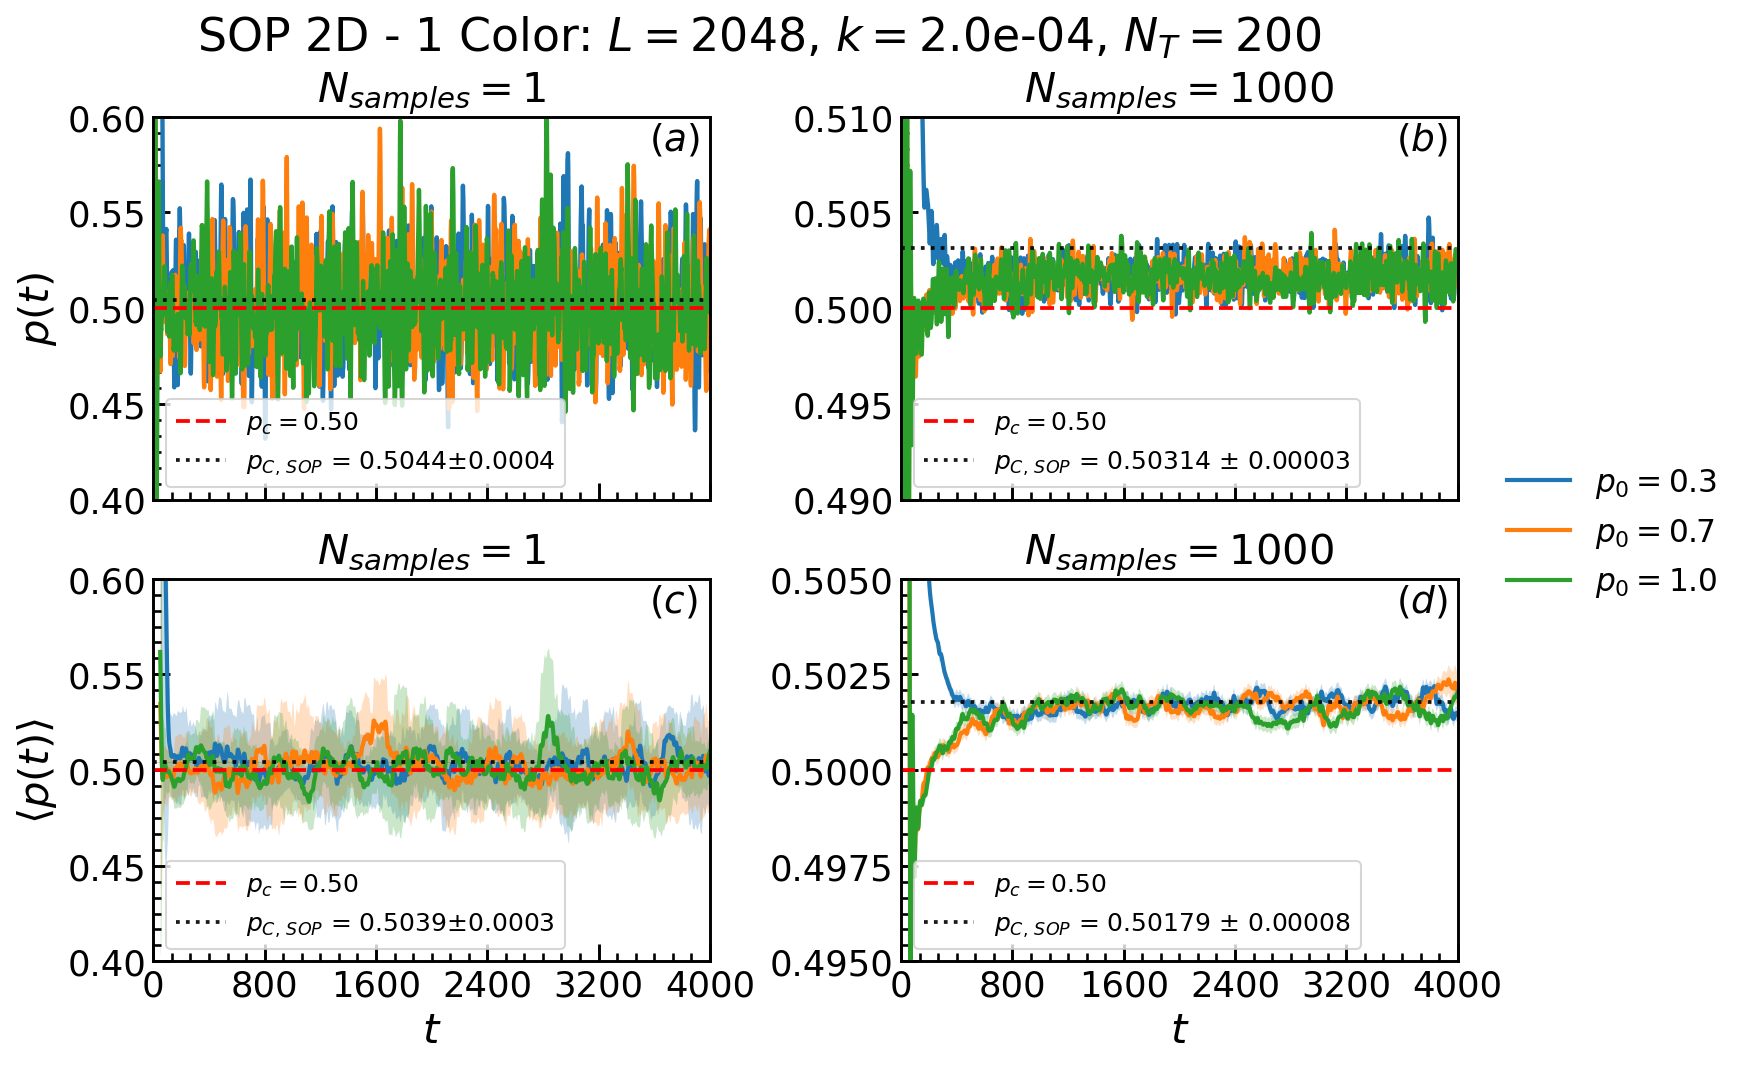

In [16]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import LinearLocator, AutoMinorLocator
from matplotlib.lines import Line2D

# ---- qualidade do PDF / render ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['savefig.dpi']  = 600
mpl.rcParams['figure.dpi']   = 150

# ---------- helpers (bootstrap) ----------
def bootstrap_mean(values, n_boot=20000, rng=None):
    """Retorna (media_boot, std_boot) via bootstrap simples sobre 'values'."""
    values = np.asarray(values, dtype=float)
    if rng is None:
        rng = np.random.default_rng(12345)
    n = values.size
    if n == 0:
        return np.nan, np.nan
    idx = rng.integers(0, n, size=(n_boot, n))
    sample_means = values[idx].mean(axis=1)
    return float(sample_means.mean()), float(sample_means.std(ddof=1))

def add_bootstrap_band(ax, pooled_values, x_max, color='k', lw=1.8, ls=':',
                       alpha_line=0.9, band_alpha=0.15, fmt="{:.4f}",
                       label_prefix=r"$\mu_{\mathrm{boot}}\pm\sigma$"):
    """Plota linha horizontal em μ_boot e faixa ±σ_boot. Retorna handle da linha com label numérico."""
    mu_b, sd_b = bootstrap_mean(pooled_values)
    ln = ax.hlines(mu_b, 0, x_max, color=color, linestyle=ls, lw=lw,
                   alpha=alpha_line, label=rf"{label_prefix} = {fmt.format(mu_b)}±{fmt.format(sd_b)}")
    ax.fill_between([0, x_max], [mu_b - sd_b, mu_b - sd_b], [mu_b + sd_b, mu_b + sd_b],
                    color=color, alpha=band_alpha, linewidth=0)
    return ln

import numpy as np

def propagate_mean_error(p_c_mean, p_c_errors):
    """
    Calcula a média e a propagação do erro para um conjunto de valores independentes.

    Parâmetros
    ----------
    p_c_mean : list[float] | np.ndarray
        Lista ou array com os valores médios p_c_i.
    p_c_errors : list[float] | np.ndarray
        Lista ou array com os erros associados σ_i (mesma ordem de p_c_mean).

    Retorna
    -------
    (p_c_m, p_c_err) : tuple[float, float]
        p_c_m   -> média aritmética simples dos valores
        p_c_err -> erro propagado da média, assumindo erros independentes
    """
    p_c_mean = np.asarray(p_c_mean, dtype=float)
    p_c_errors = np.asarray(p_c_errors, dtype=float)

    if p_c_mean.size == 0:
        return np.nan, np.nan

    N = p_c_mean.size
    p_c_m = np.mean(p_c_mean)
    p_c_err = np.sqrt(np.sum(p_c_errors**2)) / N
    return float(p_c_m), float(p_c_err)

# ---------- figura ----------
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 7), sharex=True, constrained_layout=True)

# ---------- params ----------
L = 2048
k = 2.0e-04
NT = 200
dim = 2
rho = 1.0
num_colors = 1
type_perc = 'bond'

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 17
fontsize_legend = 14
fontsize_labels = 20
thickness = 1.4

p_0_bond = [0.3, 0.7, 1.0]
seeds_name_bond = [73095449, 659078613, 1504789634]
window = 100
x_max = 4000

# --- pools para bootstrap ---
# esquerda: dados brutos
pt_pool_raw = []   # p(t)
# direita: séries suavizadas (médias móveis)
pt_pool_mu  = []   # μ_p(t)

data = load_full_bundle(type_perc, num_colors, dim, L, NT, k, rho)

# --- PLOTS (mantidos) ---
# Topo esquerdo: p(t) bruto
for i in range(len(seeds_name_bond)):
    path = f"../Data/bond_percolation/num_colors_{num_colors}/dim_{dim}/L_{L}/NT_constant/NT_{Nt}/k_{k:.1e}/rho_{rho:.4e}/data/"
    metas, df = load_bundle_old(path + f"P0_0.10_p0_{p_0_bond[i]:.2f}_seed_{seeds_name_bond[i]}.json")
    axs[0, 0].plot(df['t'], df['pt'], lw=1.5*thickness, label="_nolegend_", color=colors[i])
    mask = np.asarray(df["t"]) <= x_max
    pt_pool_raw.append(np.asarray(df["pt"])[mask])

# Topo esquerdo: p(t) all
for i in range(len(p_0_bond)):
    data_filter = data['p0_groups'][i]['orders'][0]['data']
    axs[0, 1].plot(data_filter['time'], data_filter['pt_mean'], lw=1.5*thickness, label="_nolegend_", color=colors[i])
    mask = np.asarray(data_filter['time']) <= x_max
    pt_pool_mu.append(np.asarray(data_filter["pt_mean"])[mask])

# Base esquerda: <p(t)> bruto
for i in range(len(seeds_name_bond)):
    path = f"../Data/bond_percolation/num_colors_{num_colors}/dim_{dim}/L_{L}/NT_constant/NT_{Nt}/k_{k:.1e}/rho_{rho:.4e}/data/"
    metas, df = load_bundle_old(path + f"P0_0.10_p0_{p_0_bond[i]:.2f}_seed_{seeds_name_bond[i]}.json")
    t_center, mean, std = rolling_mean_std(df['t'], df['pt'], window= 100) 
    axs[1, 0].plot(t_center, mean, lw=2.0, color=colors[i], label="_nolegend_")
    axs[1, 0].fill_between(t_center, mean - std, mean + std, alpha=0.25, color=colors[i], linewidth=0)
    # acumula os valores suavizados para bootstrap da coluna direita
    # mask_mu = np.asarray(t_center) <= x_max
    # pt_pool_mu.append(np.asarray(mu)[mask_mu])

# Topo direito: μ_p(t) ± sd
for i, seed in enumerate(seeds_name_bond):
    data_filter = B['p0_groups'][i]['pc_sop_roll']
    tc, mu, sd = data_filter['t_center'], data_filter['mean'], data_filter['std_boot']
    tc, mu, sd = np.array(tc), np.array(mu), np.array(sd)
    axs[1, 1].plot(tc, mu, lw=2.0, color=colors[i], label="_nolegend_")
    axs[1, 1].fill_between(tc, mu - sd, mu + sd, alpha=0.25, color=colors[i], linewidth=0)
    # acumula os valores suavizados para bootstrap da coluna direita
    # mask_mu = np.asarray(tc) <= x_max
    # pt_pool_mu.append(np.asarray(mu)[mask_mu])

# ===== FORMATAÇÃO =====
# linhas-guia e limites
for ax in axs[0, :]:
    ax.hlines(y=0.50, xmin=0, xmax=x_max, linestyles="--", color='r', lw=1.8)
    ax.set_ylim(0.4, 0.6)
for ax in axs[1, :]:
    ax.hlines(y=0.50, xmin=0, xmax=x_max, linestyles="--", color='r', lw=1.8)
    ax.set_ylim(0.4, 0.6)
    ax.set_xlabel(r"$t$", fontsize=fontsize_labels)
for ax in axs.flat:
    ax.set_xlim(0, x_max)
    for spine in ax.spines.values():
        spine.set_linewidth(thickness)

axs[0,0].set_ylim(0.4, 0.6)
axs[1,0].set_ylim(0.4, 0.6)
axs[0,1].set_ylim(0.49, 0.51)
axs[1,1].set_ylim(0.495, 0.505)
# rótulos, letras

letters  = [["$(a)$","$(b)$"], ["$(c)$","$(d)$"]]
titles = [[r"$N_{samples} = 1$",r"$N_{samples} = 1000$"], [r"$N_{samples} = 1$",r"$N_{samples} = 1000$"]]
for j in range(2):
    for i in range(2):
        axs[j, i].text(0.89, 0.99, letters[j][i],
                       transform=axs[j, i].transAxes,
                       ha="left", va="top", fontsize=18)
        axs[j, i].set_title(titles[j][i], fontsize=fontsize_labels)
axs[0, 0].set_ylabel(r'$p(t)$', fontsize=fontsize_labels)
axs[1, 0].set_ylabel(r'$\langle p(t) \rangle$', fontsize=fontsize_labels)

# ticks (mantidos)
for ax in axs.flat:
    ax.xaxis.set_major_locator(LinearLocator(6))
    ax.xaxis.set_minor_locator(AutoMinorLocator(6))
    ax.yaxis.set_major_locator(LinearLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(6))
    ax.tick_params(axis='both', which='major', length=8, width=thickness, labelsize=fontsize_ticks, direction='in')
    ax.tick_params(axis='both', which='minor', length=4, width=thickness*0.9, direction='in')
    ax.tick_params(axis='y', which='both', labelleft=True)    

# ===== BOOTSTRAP por coluna =====
# Esquerda: dados brutos
pt_all_raw = np.concatenate(pt_pool_raw) if len(pt_pool_raw) else np.array([])
pt_all_mu = np.concatenate(pt_pool_mu) if len(pt_pool_mu) else np.array([])
add_bootstrap_band(axs[0, 0], pt_all_raw, x_max, color='k', ls=':', label_prefix=r"$p_{C,\,SOP}$")
add_bootstrap_band(axs[1, 0], pt_all_mu, x_max, color='k', ls=':', label_prefix=r"$p_{C,\,SOP}$")

#  Avarage to all data
pc_all_data = [data['p0_groups'][i]['pc_sop']['mean'] for i in range(3)]
pc_all_err_data = [data['p0_groups'][i]['pc_sop']['std_boot'] for i in range(3)]
pc_mean_all, pc_mean_err = propagate_mean_error(pc_all_data, pc_all_err_data)

axs[0, 1].hlines(pc_mean_all, 0, x_max, color='k', linestyle=':', lw=1.8,
                alpha=0.9, label=fr"$p_{{C,\,SOP}}$ = {pc_mean_all:.5f} ± {pc_mean_err:.5f}")

# Avarage to all data rolling
pc_all_data_roll = [data['p0_groups'][i]['pc_sop_roll']['tail_summary']['mean'] for i in range(3)]
pc_all_err_data_roll = [data['p0_groups'][i]['pc_sop_roll']['tail_summary']['std_boot'] for i in range(3)]
pc_mean_all_roll, pc_mean_err_roll = propagate_mean_error(pc_all_data_roll, pc_all_err_data_roll)

axs[1, 1].hlines(pc_mean_all_roll, 0, x_max, color='k', linestyle=':', lw=1.8,
                alpha=0.9, label=fr"$p_{{C,\,SOP}}$ = {pc_mean_all_roll:.5f} ± {pc_mean_err_roll:.5f}")

# # Direita: séries suavizadas (μ)
# pt_all_mu  = np.concatenate(pt_pool_mu)  if len(pt_pool_mu)  else np.array([])
# nt_all_mu  = np.concatenate(nt_pool_mu)  if len(nt_pool_mu)  else np.array([])
# add_bootstrap_band(axs[1, 0], pt_all_mu, x_max, color='k', ls=':', label_prefix=r"$p_{C,\,SOP}$")
# add_bootstrap_band(axs[1, 1], nt_all_mu, x_max, color='k', ls=':', label_prefix=r"$N_{mean,\,SOP}$")

# ===== Legendas =====
handles_p0 = [Line2D([0],[0], color=colors[i], lw=2.0, label=fr"$p_0 = {p_0_bond[i]}$")
              for i in range(len(p_0_bond))]

fig.suptitle(f"SOP 2D - 1 Color: $L={L}$, $k=${k:.1e}, $N_T = {Nt}$", fontsize=22)

# legenda externa (direita)
fig.legend(handles=handles_p0, loc='center left', bbox_to_anchor=(0.98, 0.50),
           frameon=False, fontsize=15)

# legendas internas
ref_handle_pt = Line2D([0],[0], color='r', lw=1.8, ls='--', label=r"$p_c = 0.50$")
ref_handle_nt = Line2D([0],[0], color='r', lw=1.8, ls='--', label=r"$p_c = 0.50$")

for ax in axs[0, :]:
    h, l = ax.get_legend_handles_labels()
    ax.legend([ref_handle_pt, *h], [ref_handle_pt.get_label(), *l],
              loc='lower left', fontsize=12, frameon=True)
for ax in axs[1, :]:
    h, l = ax.get_legend_handles_labels()
    ax.legend([ref_handle_nt, *h], [ref_handle_nt.get_label(), *l],
              loc='lower left', fontsize=12, frameon=True)

# ===== SALVAR =====
savepath = savepath_TS_1color + "/props_L_2048_multi_with_zoom.pdf"
fig.savefig(savepath, bbox_inches="tight", pad_inches=0.10, dpi=600)
plt.show()

## 2 COLORS